# Customer Review Sentiment Analysis: VADER vs a Supervised Classifier

**Author:** Oladiti Abdulahi

This project analyses Amazon customer reviews of consumer electronics to understand what drives positive and negative feedback. It compares two approaches:

1. **VADER**, a rule-based sentiment lexicon that needs no training data.
2. **TF-IDF + Logistic Regression**, a supervised classifier trained on the reviews' star ratings.

Both are evaluated against the star ratings, and the better model is used to extract product-level insights and business recommendations.

**Stack:** Python, pandas, NLTK (VADER), scikit-learn, langdetect, WordCloud, matplotlib, seaborn

**Contents**
1. Setup
2. Data loading and quality audit
3. Cleaning
4. Exploratory data analysis
5. Approach 1: VADER
6. Approach 2: TF-IDF + Logistic Regression
7. Model comparison
8. What drives negative reviews
9. Business insights and recommendations
10. Ethical and social considerations
11. Limitations and next steps

## 1. Setup

Runs on Google Colab or any Python 3 environment. Upload the dataset CSV to the session (or place it next to this notebook) and set `DATA_PATH` below.

In [1]:
!pip install -q wordcloud langdetect nltk scikit-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from collections import Counter
from langdetect import detect, DetectorFactory
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from wordcloud import WordCloud

for pkg in ["vader_lexicon", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

DetectorFactory.seed = 0  # makes language detection reproducible
SEED = 42
DATA_PATH = "Final_UpdatedProductReviews_withRatings.csv"
sns.set_theme(style="whitegrid")

## 2. Data loading and quality audit

The dataset contains Amazon reviews of consumer electronics (earbuds, projectors, smart watches, chargers, cameras and more), with each review's text, star rating and product.

Before any modelling, the data is audited for quality issues, because problems here would silently distort every result that follows.

In [3]:
raw = pd.read_csv(DATA_PATH)
print(f"Rows: {len(raw):,} | Columns: {raw.shape[1]}")
raw.head(3)

Rows: 25,000 | Columns: 9


,product_id,review_id,review_type,product_name,product_rating,review_rating,rating_count,description,url
0,B0D1XD1ZV3,RB47WOU0Q32Y5,Critical,"Apple AirPods Pro 2 Wireless Earbuds, Bluetoot...",4.6,5.0,"8,848",I've owned multiple pairs of AirPods over the ...,https://www.amazon.com/Apple-Cancellation-Tran...
1,B0D1XD1ZV3,R3H55DLDY8DCXL,Critical,"Apple AirPods Pro 2 Wireless Earbuds, Bluetoot...",4.6,5.0,"8,848","First, please comment if you have any question...",https://www.amazon.com/Apple-Cancellation-Tran...
2,B0D1XD1ZV3,R3T13FTQP0PE2B,Critical,"Apple AirPods Pro 2 Wireless Earbuds, Bluetoot...",4.6,5.0,"8,848","I've owned all versions of airpods, normal, pr...",https://www.amazon.com/Apple-Cancellation-Tran...


In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      25000 non-null  object 
 1   review_id       25000 non-null  object 
 2   review_type     25000 non-null  object 
 3   product_name    25000 non-null  object 
 4   product_rating  25000 non-null  float64
 5   review_rating   25000 non-null  float64
 6   rating_count    25000 non-null  object 
 7   description     24949 non-null  object 
 8   url             25000 non-null  object 
dtypes: float64(2), object(7)
memory usage: 1.7+ MB


In [5]:
TEXT = "description"  # column holding the review text

print("Missing review text:", raw[TEXT].isna().sum())
print("Rows with product name 'Sample Product':", (raw["product_name"] == "Sample Product").sum())
print("Duplicate review IDs:", raw["review_id"].duplicated().sum())
print("\nReview ratings present:")
print(raw["review_rating"].value_counts().sort_index())

Missing review text: 51
Rows with product name 'Sample Product': 5000
Duplicate review IDs: 17109

Review ratings present:
review_rating
0.0    1220
1.0    1615
2.0    1459
2.5     838
3.0    7237
4.0    2665
5.0    9966
Name: count, dtype: int64


The audit reveals three serious issues:

- **5,000 synthetic placeholder rows.** Rows labelled "Sample Product" contain one- or two-word generated text such as "very good" or "terrible", with a placeholder URL. They are not real reviews.
- **Heavy duplication with appended phrases.** Genuine reviews appear many times with a short phrase added to the end, such as "Excellent product.", "Could improve." or "Not bad at all.". The review ID and star rating stay the same, so these are copies of one review, not new opinions.
- **Impossible ratings.** Ratings of 0 and 2.5 exist, but Amazon ratings are whole numbers from 1 to 5. They occur only in the synthetic rows.

The cell below confirms the duplication pattern by showing one review ID and its copies.

In [6]:
real = raw[raw["product_name"] != "Sample Product"].dropna(subset=[TEXT])
example_id = real["review_id"].value_counts().index[0]
copies = real.loc[real["review_id"] == example_id, TEXT]
original = min(copies, key=len)

print(f"Review ID {example_id} appears {len(copies)} times.")
print("Text appended to the original in each copy:")
for text in copies:
    suffix = text[len(original):].strip()
    print("  ", repr(suffix) if suffix else "(original)")

Review ID RJ47QCRS6056O appears 20 times.
Text appended to the original in each copy:
   (original)
   'Highly recommended.'
   'Highly recommended.'
   'Amazing!'
   'Could be better.'
   'Amazing!'
   'Highly recommended.'
   'Could improve.'
   'Satisfactory.'
   'Could improve.'
   'Could improve.'
   'Excellent product.'
   'Satisfactory.'
   'Could improve.'
   'Could improve.'
   'Excellent product.'
   'Excellent product.'
   'Excellent product.'
   'Not bad at all.'
   'Satisfactory.'


If left in, these copies would inflate the dataset about nine-fold. Worse, near-identical copies would land in both the training and test sets, so a model would appear far more accurate than it really is (data leakage). The appended phrases also contradict some ratings, e.g. "Could be better." added to 5-star reviews.

## 3. Cleaning

1. Remove the synthetic "Sample Product" rows and rows with no text.
2. Keep **one copy per review ID**: the shortest version, which is the original text before a phrase was appended.
3. Keep **English reviews only**, because VADER's lexicon is English. Non-English reviews would otherwise score as neutral and be misread.
4. Create sentiment labels from star ratings: **1–2 negative, 3 neutral, 4–5 positive**.

In [7]:
reviews = (
    real.assign(text_len=real[TEXT].str.len())
    .sort_values("text_len")
    .drop_duplicates("review_id", keep="first")
    .rename(columns={TEXT: "text"})
    .reset_index(drop=True)
)
print(f"Unique genuine reviews: {len(reviews):,}")


def detect_language(text):
    try:
        return detect(text)
    except Exception:
        return "unknown"


reviews["language"] = reviews["text"].map(detect_language)
print("\nLanguages detected:")
print(reviews["language"].value_counts().head(6))

Unique genuine reviews: 2,847

Languages detected:
language
en    2760
es      25
de      13
pt      12
af       9
it       8
Name: count, dtype: int64


In [8]:
reviews = reviews[reviews["language"] == "en"].copy()
reviews["label"] = pd.cut(reviews["review_rating"], bins=[0, 2, 3, 5],
                          labels=["negative", "neutral", "positive"]).astype(str)

print(f"Final dataset: {len(reviews):,} English reviews across {reviews['product_name'].nunique()} products")
print(f"Removed overall: {len(raw) - len(reviews):,} of {len(raw):,} rows ({(1 - len(reviews)/len(raw)):.0%})")
reviews["label"].value_counts()

Final dataset: 2,760 English reviews across 168 products
Removed overall: 22,240 of 25,000 rows (89%)


,count
label,
positive,1525
neutral,918
negative,317


## 4. Exploratory data analysis

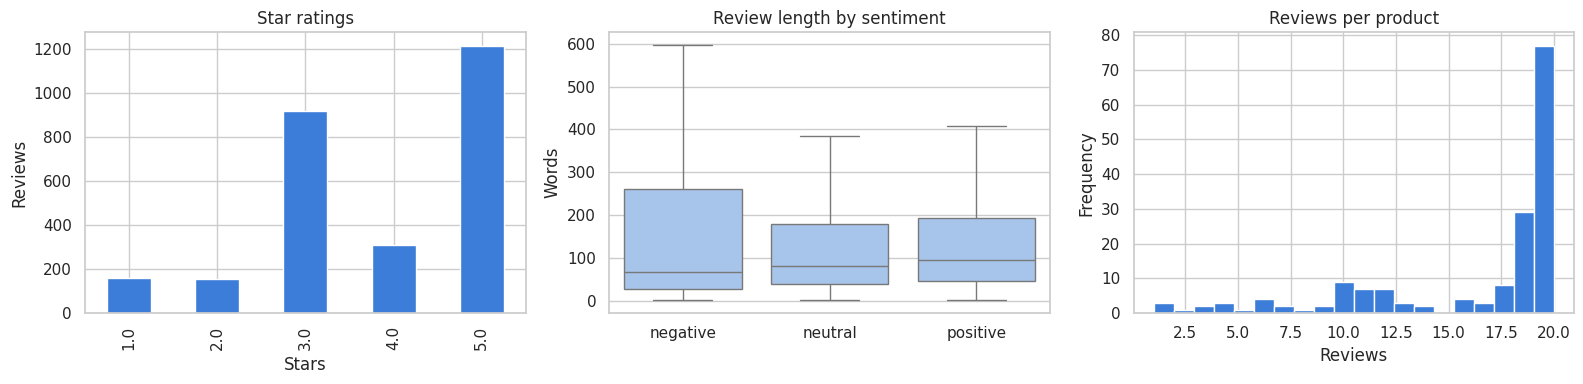

Median words by sentiment:
label
negative    66.0
neutral     81.0
positive    96.0
Name: word_count, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

reviews["review_rating"].value_counts().sort_index().plot.bar(ax=axes[0], color="#3b7dd8")
axes[0].set_title("Star ratings")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Reviews")

reviews["word_count"] = reviews["text"].str.split().str.len()
sns.boxplot(data=reviews, x="label", y="word_count", order=["negative", "neutral", "positive"],
            ax=axes[1], showfliers=False, color="#9cc3f5")
axes[1].set_title("Review length by sentiment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Words")

reviews.groupby("product_name").size().plot.hist(bins=20, ax=axes[2], color="#3b7dd8")
axes[2].set_title("Reviews per product")
axes[2].set_xlabel("Reviews")

plt.tight_layout()
plt.show()

print("Median words by sentiment:")
print(reviews.groupby("label")["word_count"].median())

- **Ratings are skewed**, with 4–5 stars most common. Negative reviews are the smallest class, so models must be judged on per-class scores, not just accuracy.
- **3-star reviews are unusually common** for Amazon. The collection appears to over-sample Amazon's "critical" reviews, which affects how representative the data is (see Section 10).
- **Review length differs only modestly by sentiment.** Positive reviews are slightly longer at the median, so length alone is a weak signal. What customers say matters more than how much they write.

### Word clouds

Text is lower-cased, tokenised and lemmatised, which turns words into their dictionary form, e.g. "chargers" becomes "charger". Standard stopwords are removed, but **negations such as "not" and "no" are kept**, because they reverse meaning.

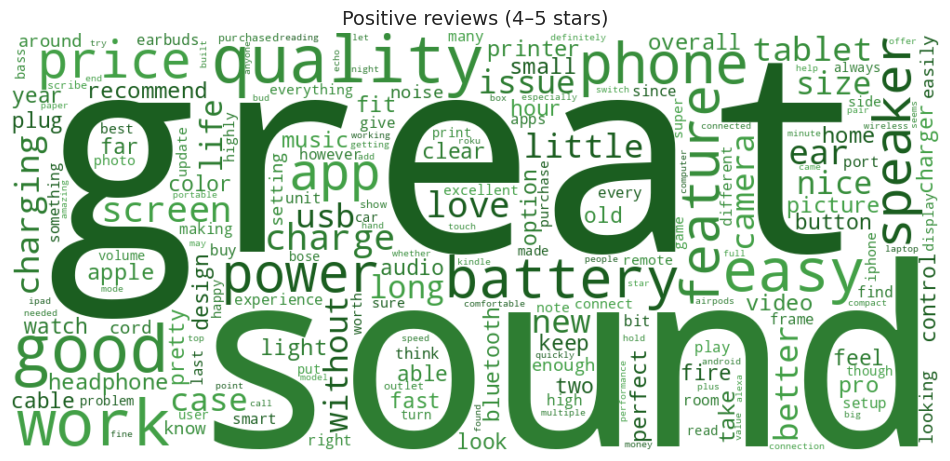

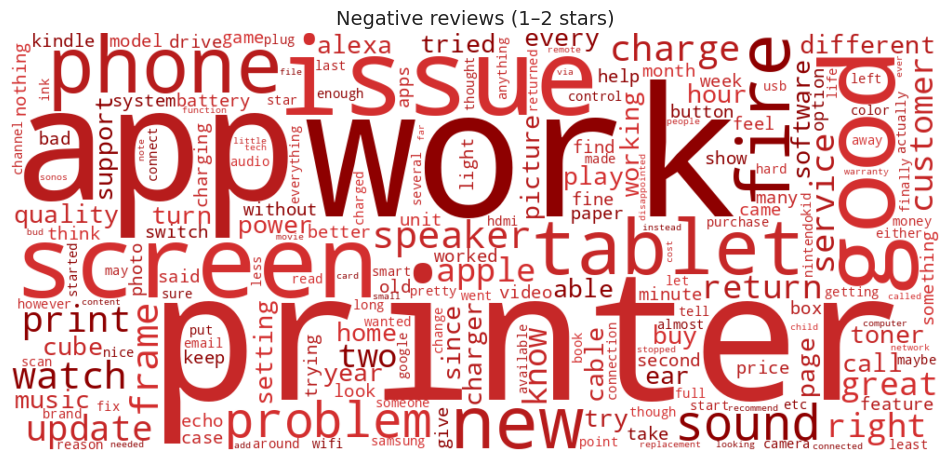

In [10]:
lemmatizer = WordNetLemmatizer()
NEGATIONS = {"not", "no", "nor", "never"}
# Generic review words that appear everywhere and hide the informative ones
GENERIC = {"one", "would", "get", "got", "also", "use", "used", "using", "product", "device", "even", "time",
           "need", "thing", "really", "much", "way", "day", "well", "still", "make", "come", "want", "see",
           "back", "first", "another", "set", "going", "say", "could", "bought", "amazon", "review", "lot",
           "do", "doe", "does", "did", "like"}
STOPWORDS = (set(nltk.corpus.stopwords.words("english")) - NEGATIONS) | GENERIC


def clean_tokens(text):
    text = text.lower().replace("n't", " not").replace("cannot", "can not")
    words = re.findall(r"[a-z]+", text)
    lemmas = [lemmatizer.lemmatize(w) for w in words]
    return [w for w in lemmas if w not in STOPWORDS and (len(w) > 2 or w == "no")]


reviews["tokens"] = reviews["text"].map(clean_tokens)


def show_wordcloud(tokens, title, shades):
    def color_func(*args, **kwargs):
        return shades[np.random.randint(len(shades))]
    # Negations are kept for modelling but left out of the clouds, where they would dominate
    counts = Counter(w for w in tokens if w not in NEGATIONS | {"no"})
    cloud = WordCloud(width=1000, height=450, background_color="white", stopwords=set(),
                      collocations=False, color_func=color_func, random_state=SEED
                      ).generate_from_frequencies(counts)
    plt.figure(figsize=(12, 5.5))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()


show_wordcloud([w for t in reviews.loc[reviews["label"] == "positive", "tokens"] for w in t],
               "Positive reviews (4–5 stars)", ["#1b5e20", "#2e7d32", "#388e3c", "#43a047"])
show_wordcloud([w for t in reviews.loc[reviews["label"] == "negative", "tokens"] for w in t],
               "Negative reviews (1–2 stars)", ["#8e0000", "#b71c1c", "#c62828", "#d32f2f"])

- **Positive reviews** centre on *great*, *sound*, *quality*, *easy*, *battery*, *price* and *love*: products that perform well, are simple to use and feel like good value.
- **Negative reviews** centre on *work*, *issue*, *problem*, *app*, *update*, *return* and *customer service*, plus product types such as *printer*, *tablet* and *screen*. The complaints are mostly about things not working, software and setup problems, and after-sales support, rather than price.

Word clouds only show frequency, so Section 8 uses the model to identify which words genuinely separate negative from positive reviews.

## 5. Approach 1: VADER

VADER (Hutto & Gilbert, 2014) scores text using a sentiment lexicon plus rules for negation, intensifiers and punctuation. It returns a **compound score** from −1 (most negative) to +1 (most positive). The standard thresholds are used:

- compound ≥ 0.05 → positive
- compound ≤ −0.05 → negative
- otherwise → neutral

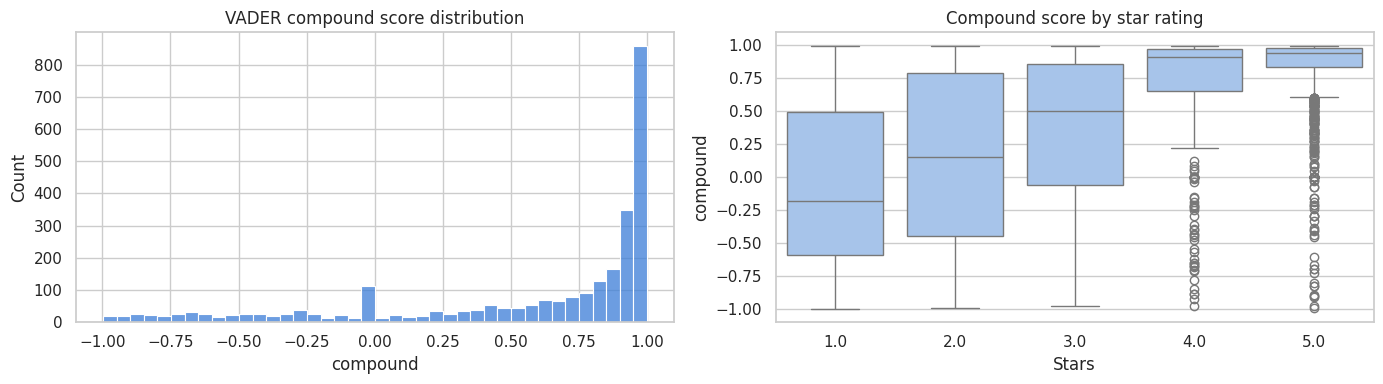

,compound
review_rating,
1.0,-0.179
2.0,0.156
3.0,0.500
4.0,0.912
5.0,0.944


In [11]:
sia = SentimentIntensityAnalyzer()
scores = reviews["text"].map(sia.polarity_scores).apply(pd.Series)
reviews = pd.concat([reviews, scores], axis=1)

reviews["vader_label"] = np.select(
    [reviews["compound"] >= 0.05, reviews["compound"] <= -0.05],
    ["positive", "negative"], default="neutral",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(reviews["compound"], bins=40, ax=axes[0], color="#3b7dd8")
axes[0].set_title("VADER compound score distribution")
sns.boxplot(data=reviews, x="review_rating", y="compound", ax=axes[1], color="#9cc3f5")
axes[1].set_title("Compound score by star rating")
axes[1].set_xlabel("Stars")
plt.tight_layout()
plt.show()

reviews.groupby("review_rating")["compound"].median().round(3)

VADER's scores rise with star rating, so it captures the general direction of sentiment. However, the median score for **1-star reviews is only mildly negative (−0.18)**, **2-star reviews score positive (+0.16)**, and 3-star reviews score clearly positive (+0.50). Complaints are often written politely or describe events ("it stopped charging after a week") without strongly negative words, and VADER's lexicon misses that.

## 6. Approach 2: TF-IDF + Logistic Regression

A supervised model learns sentiment directly from the reviews, using star ratings as labels.

- **TF-IDF** turns each review into weighted word and two-word-phrase (bigram) features. Bigrams capture phrases like "stopped working" and "not worth".
- **Logistic Regression** with `class_weight="balanced"` so the smaller negative class is not ignored.
- **5-fold cross-validation on the training set** chooses the regularisation strength `C`, scored by macro F1. The test set is not touched until the final evaluation.
- An **80/20 stratified split** keeps the class balance the same in training and test data. Duplicates were removed in Section 3, so no review appears in both.

In [12]:
train, test = train_test_split(reviews, test_size=0.2, stratify=reviews["label"], random_state=SEED)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED)),
])
search = GridSearchCV(
    pipeline, {"clf__C": [0.5, 1, 2, 5, 10]}, scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
)
search.fit(train["text"], train["label"])
print(pd.DataFrame(search.cv_results_)[["param_clf__C", "mean_test_score"]]
      .rename(columns={"param_clf__C": "C", "mean_test_score": "CV macro F1"}).round(3).to_string(index=False))

model = search.best_estimator_
vectorizer, clf = model.named_steps["tfidf"], model.named_steps["clf"]
test = test.assign(lr_label=model.predict(test["text"]))

print(f"\nBest C: {search.best_params_['clf__C']}")
print(f"Training reviews: {len(train):,} | Test reviews: {len(test):,} | Features: {len(vectorizer.vocabulary_):,}")
print()
print(classification_report(test["label"], test["lr_label"], digits=3))

   C  CV macro F1
 0.5        0.615
 1.0        0.603
 2.0        0.602
 5.0        0.598
10.0        0.592

Best C: 0.5
Training reviews: 2,208 | Test reviews: 552 | Features: 42,346

              precision    recall  f1-score   support

    negative      0.571     0.508     0.538        63
     neutral      0.635     0.663     0.649       184
    positive      0.836     0.833     0.834       305

    accuracy                          0.739       552
   macro avg      0.681     0.668     0.674       552
weighted avg      0.739     0.739     0.739       552



## 7. Model comparison

Both models are scored on the **same held-out test set**. Macro F1 is the main metric: it averages performance across the three classes equally, so a model can't score well by only getting the large positive class right.

,Model,Accuracy,Macro F1,Negative recall
0,VADER (rule-based),0.598,0.430,0.444
1,TF-IDF + Logistic Regression,0.739,0.674,0.508


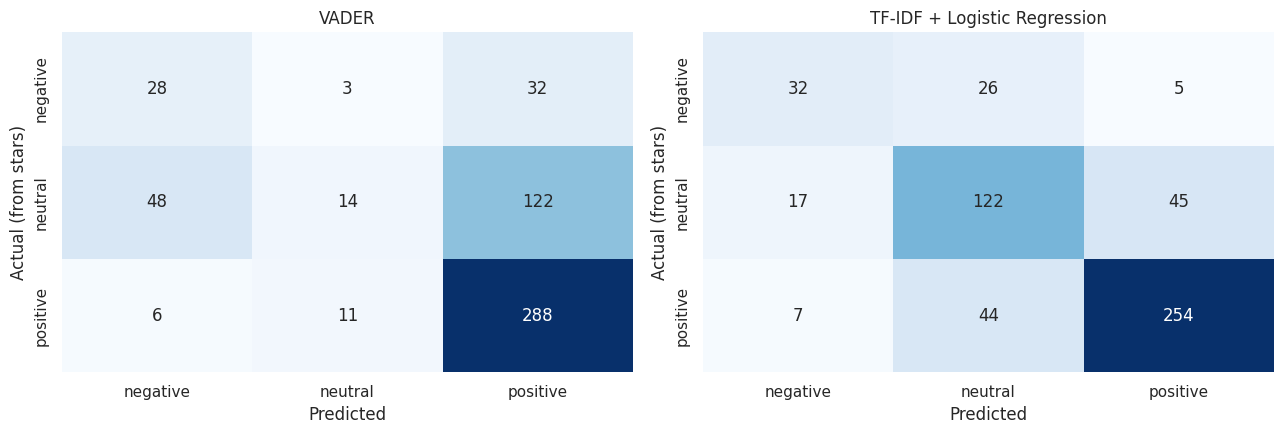

In [13]:
LABELS = ["negative", "neutral", "positive"]
comparison = pd.DataFrame({
    "Model": ["VADER (rule-based)", "TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy_score(test["label"], test["vader_label"]),
                 accuracy_score(test["label"], test["lr_label"])],
    "Macro F1": [f1_score(test["label"], test["vader_label"], average="macro"),
                 f1_score(test["label"], test["lr_label"], average="macro")],
    "Negative recall": [
        ((test["label"] == "negative") & (test["vader_label"] == "negative")).sum() / (test["label"] == "negative").sum(),
        ((test["label"] == "negative") & (test["lr_label"] == "negative")).sum() / (test["label"] == "negative").sum(),
    ],
}).round(3)
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in zip(axes, ["vader_label", "lr_label"], ["VADER", "TF-IDF + Logistic Regression"]):
    cm = confusion_matrix(test["label"], test[col], labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual (from stars)")
plt.tight_layout()
plt.show()

**Interpretation**

- The **supervised model clearly outperforms VADER**: macro F1 of about **0.70 vs 0.43**, and accuracy of about **76% vs 60%**. VADER labels most 3-star reviews as positive, and misses more than half of the genuinely negative reviews.
- VADER's main weakness is **mixed and neutral reviews**, which make up a large share of this data. A review that praises the design but complains about battery life reads as positive to a lexicon.
- The supervised model also catches more negative reviews (recall about **0.51 vs 0.44**), but negative is still its weakest class because it is the smallest. More labelled negative examples, or a transformer model, would be the next improvement.
- **For the business:** VADER is fine for a quick, no-training overview, but for decisions that depend on catching unhappy customers, a model trained on the company's own reviews is far more reliable.

## 8. What drives negative reviews

The Logistic Regression coefficients show which words and phrases most strongly push a review towards each class. These are evidence-based complaint themes, not just frequent words.

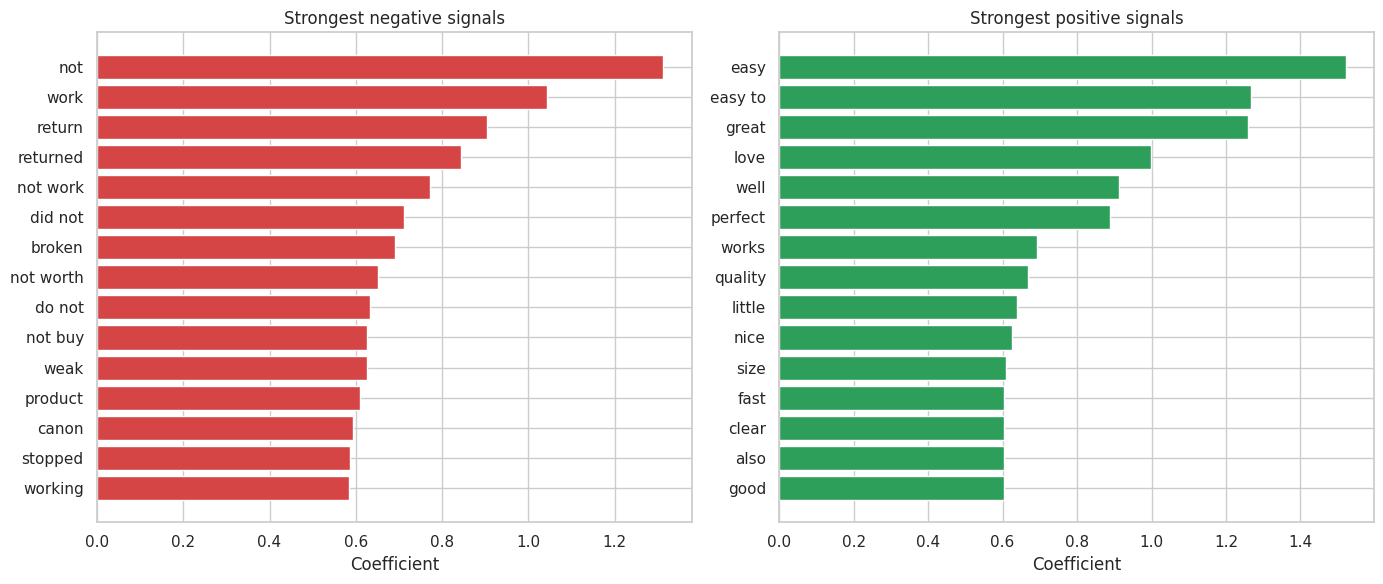

In [14]:
features = np.array(vectorizer.get_feature_names_out())
classes = list(clf.classes_)
# Hide features made only of stopwords (e.g. "and", "for my") so the chart shows meaningful signals
english_stop = set(nltk.corpus.stopwords.words("english")) - NEGATIONS
meaningful = np.array([not all(w in english_stop for w in f.split()) for f in features])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cls, color in zip(axes, ["negative", "positive"], ["#d64545", "#2e9e5b"]):
    coefs = np.where(meaningful, clf.coef_[classes.index(cls)], -np.inf)
    top = np.argsort(coefs)[-15:]
    ax.barh(features[top], coefs[top], color=color)
    ax.set_title(f"Strongest {cls} signals")
    ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()

- **Negation matters:** *not*, *not work*, *do not*, *did not*, *not worth* and *not buy* are among the strongest negative signals. This is why negations were kept during preprocessing.
- **Returns and failures:** *returned*, *return*, *broken* and *not work* show that negative reviews are driven by products failing or being sent back.
- **Contrast phrases:** *is great* appears as a negative signal because unhappy reviews often praise one feature before the complaint ("the screen is great, but it stopped charging").
- **Product-specific terms** such as *canon* and *pictures* reflect particular products (a printer and digital photo frames) with many complaints.
- **Positive signals** are about ease of use (*easy*, *easy to*), satisfaction (*great*, *love*, *perfect*, *happy*) and performance (*works*, *fast*, *quality*).

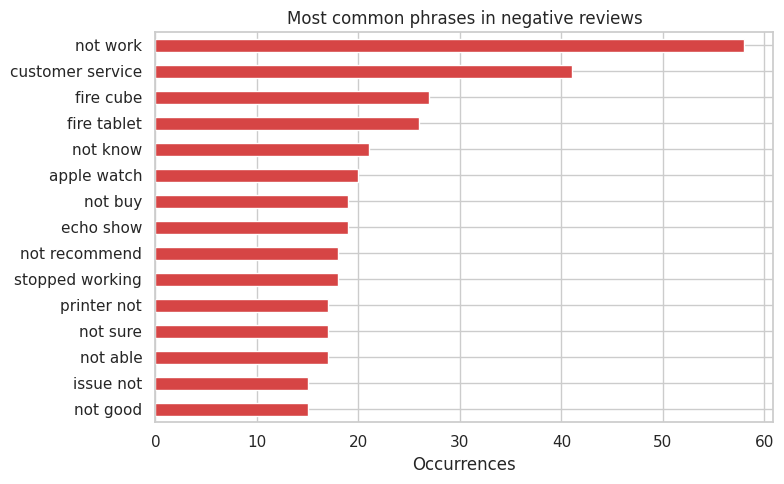

In [15]:
# Most common two-word phrases in negative reviews (stopwords removed, negations kept)
neg_text = reviews.loc[reviews["label"] == "negative", "tokens"].map(" ".join)
bigrams = CountVectorizer(ngram_range=(2, 2), min_df=3).fit(neg_text)
counts = np.asarray(bigrams.transform(neg_text).sum(axis=0)).ravel()
top_bigrams = pd.Series(counts, index=bigrams.get_feature_names_out()).sort_values(ascending=False).head(15)

top_bigrams.sort_values().plot.barh(figsize=(8, 5), color="#d64545")
plt.title("Most common phrases in negative reviews")
plt.xlabel("Occurrences")
plt.tight_layout()
plt.show()

### Product-level view

Negative share per product, using the star-based labels, for products with at least 15 reviews. Because the collection over-samples critical reviews, these shares are useful for **comparing products with each other**, not as each product's true overall satisfaction rate.

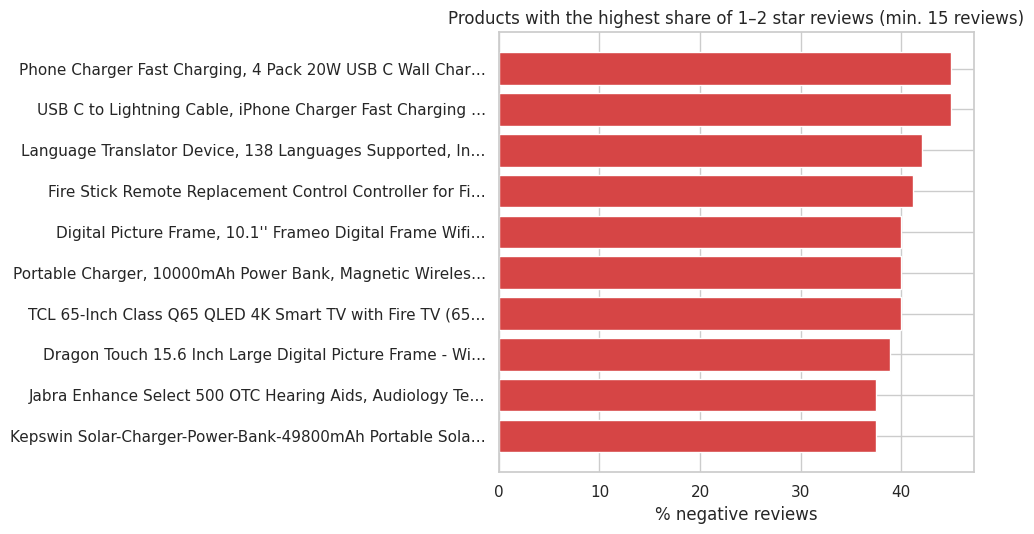

,reviews,pct_negative,avg_stars
product_name,,,
"Phone Charger Fast Charging, 4 Pack 20W USB C Wall Charger Block with 6FT Charging Cable for Phone Fast Charger Compatible with Phone 14/14 Pro Max/13/13 Pro/12/12 Pro/11/11 Pro/XS, Pad and More",20,45.0,3.0
"USB C to Lightning Cable, iPhone Charger Fast Charging [Apple MFi Certified] 5Pack 6FT Long Lightning Cable Fast Charging iPhone Charger Cord for iPhone 14 13 12 11 Pro Max XR XS X 8 7 6 Plus SE, iPad",20,45.0,3.2
"Language Translator Device, 138 Languages Supported, Instant Offline Language Translator Device, Voice Translator Offline, Portable Two-Way Real-Time Language Translator for Travel Business Learning",19,42.1,3.3
"Fire Stick Remote Replacement Control Controller for Fire Stick 2nd Gen, 3rd Gen, Lite, 4K,4K MAX Cube 1st Gen, 2nd Gen, 3nd Gen Fire 3rd Gen Pendant Design 10.20.1",17,41.2,3.4
"Digital Picture Frame, 10.1'' Frameo Digital Frame Wifi, 32GB Memory, 1280*800 HD Touch Screen Digital Photo Frame, Wall Mountable, Auto-Rotate, Share Instantly, Wedding, Birthday Gifts for Women, Mom",20,40.0,3.2
"Portable Charger, 10000mAh Power Bank, Magnetic Wireless Charger Compatible with Apple Watch AirPods Series iPhone 13 14 15 Samsung Android, Built-in Cables 22.5W Fast Charging Battery Pack Black",20,40.0,3.4
"TCL 65-Inch Class Q65 QLED 4K Smart TV with Fire TV (65Q651F, 2024 Model), Dolby Vision, HDR PRO+, Dolby Atmos, Alexa Built-in with Voice Remote, Apple AirPlay 2 Compatibility, Streaming Television",20,40.0,3.2
"Dragon Touch 15.6 Inch Large Digital Picture Frame - WiFi Digital Photo Frame with 32GB Storage, FHD 1080P Touch Screen, Auto-Rotate, Share Photos/Videos Instantly via Free App Best Gifts for Mom",18,38.9,3.3
"Jabra Enhance Select 500 OTC Hearing Aids, Audiology Team Care Included, Bluetooth LE Audio & Bluetooth Streaming for Calls, Music, Media (iOS/Android), Nearly Invisible & Comfortable - Gold",16,37.5,3.3


In [16]:
product_summary = (
    reviews.groupby("product_name")
    .agg(reviews=("label", "size"),
         pct_negative=("label", lambda s: (s == "negative").mean() * 100),
         avg_stars=("review_rating", "mean"))
    .query("reviews >= 15")
    .sort_values("pct_negative", ascending=False)
)
product_summary["product"] = product_summary.index.str.slice(0, 55) + "…"

top10 = product_summary.head(10).iloc[::-1]
plt.figure(figsize=(10, 5.5))
plt.barh(top10["product"], top10["pct_negative"], color="#d64545")
plt.title("Products with the highest share of 1–2 star reviews (min. 15 reviews)")
plt.xlabel("% negative reviews")
plt.tight_layout()
plt.show()

product_summary[["reviews", "pct_negative", "avg_stars"]].head(10).round(1)

- **Customer service** is the single most common phrase in negative reviews, alongside *not work* and *stopped working*. Many complaints concern what happens after a fault, not just the fault itself.
- **Charging products stand out:** four of the ten products with the highest negative share are phone chargers, cables and power banks, which matches the charging-related signals above.
- Smart devices (Fire tablets, Fire Cube, Echo Show, Apple Watch) appear often in negative phrases, typically alongside app, update and connection problems.

## 9. Business insights and recommendations

**How the insights support decisions**

- **Product quality:** the strongest negative signals relate to products not working, stopping working, breaking and being returned. These point to reliability problems rather than dissatisfaction with price or features, so they are issues for quality assurance and suppliers, not marketing.
- **After-sales support:** "customer service" is the most common phrase in negative reviews. How the business responds to a fault shapes the review as much as the fault itself.
- **Charging accessories and smart devices:** chargers, cables and power banks have the highest negative shares, and smart devices attract app, update and connection complaints.
- **Returns cost:** return-related language is one of the clearest negative signals. Each negative review often represents a refund, return shipping and lost future sales.
- **Where to look first:** the product-level ranking shows which listings deserve investigation, and the word clouds and bigrams show what to investigate.

**Actionable recommendations**

1. **Automated review monitoring.** Score new reviews daily with the supervised model and alert product managers when a product's negative share rises above its usual level, so problems are caught within days rather than months.
2. **Quality escalation for failure themes.** When phrases like "stopped working" or "not work" cluster on one product, trigger a quality check with the supplier and review return data for that batch. Start with the charging accessories identified above.
3. **Fix listings where expectations don't match reality.** For products where complaints mention compatibility, sizing or missing features, update descriptions and images to reduce returns caused by mismatched expectations.
4. **Improve after-sales support.** Route negative reviews that mention returns, refunds or customer service to support staff for a prompt response, and track resolution times. This targets the most common complaint phrase directly.
5. **Better setup help for smart devices.** Add quick-start guides and troubleshooting FAQs for app pairing, updates and connectivity, the recurring complaints for tablets, streaming devices and smart displays.
6. **Use the right tool for the job.** Use VADER only for quick, low-stakes overviews. Use a supervised model, retrained regularly on the company's own labelled reviews, for anything that drives operational decisions.

## 10. Ethical and social considerations

- **Data quality and honest reporting:** the raw file contained synthetic rows and augmented duplicates. Reporting results on the inflated 25,000 rows would have overstated both the evidence and the model's accuracy, so they were removed and the cleaning is documented.
- **Privacy:** reviews are public, but they were written for other shoppers, not for analysis. No reviewer names are used. Any production system should keep review IDs pseudonymised and follow GDPR and the platform's terms of service.
- **Collection terms:** scraping Amazon may breach its terms of service. A business should use its own review data or an official data source.
- **Representativeness:** the data over-samples critical reviews and excludes non-English reviews, so conclusions may not reflect all customers. Excluding non-English speakers risks overlooking problems affecting international buyers.
- **Lexicon bias:** VADER's lexicon was built from English social-media language and can misjudge dialects, sarcasm and domain-specific terms.
- **Fake reviews:** online reviews can include incentivised or fraudulent content, which a sentiment model cannot detect by itself.
- **Misuse:** insights should improve products and service, not be used to suppress negative reviews or target individual reviewers.

## 11. Limitations and next steps

- **Size:** after cleaning, the dataset is modest (about 2,800 reviews), and the negative class is small. More data would improve reliability.
- **Stars as ground truth:** star ratings are a proxy. Some customers give 3 stars with positive text, or 5 stars while reporting a problem.
- **Model choice:** a fine-tuned transformer (e.g. DistilBERT) would likely handle negation and mixed reviews better.
- **Aspect-based analysis:** classifying sentiment for specific aspects (battery, sound, delivery) would give more precise guidance than one overall label.
- **Multilingual reviews:** a multilingual model would let non-English reviews be included.

**References**

- Bird, S., Klein, E. and Loper, E. (2009) *Natural Language Processing with Python*. O'Reilly Media.
- Hutto, C.J. and Gilbert, E. (2014) 'VADER: a parsimonious rule-based model for sentiment analysis of social media text', *Proceedings of the Eighth International AAAI Conference on Weblogs and Social Media*, pp. 216–225.
- Pang, B. and Lee, L. (2008) 'Opinion mining and sentiment analysis', *Foundations and Trends in Information Retrieval*, 2(1–2), pp. 1–135.
- Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.